In [1]:
import numpy as np
import scipy
from matplotlib import pyplot as pl

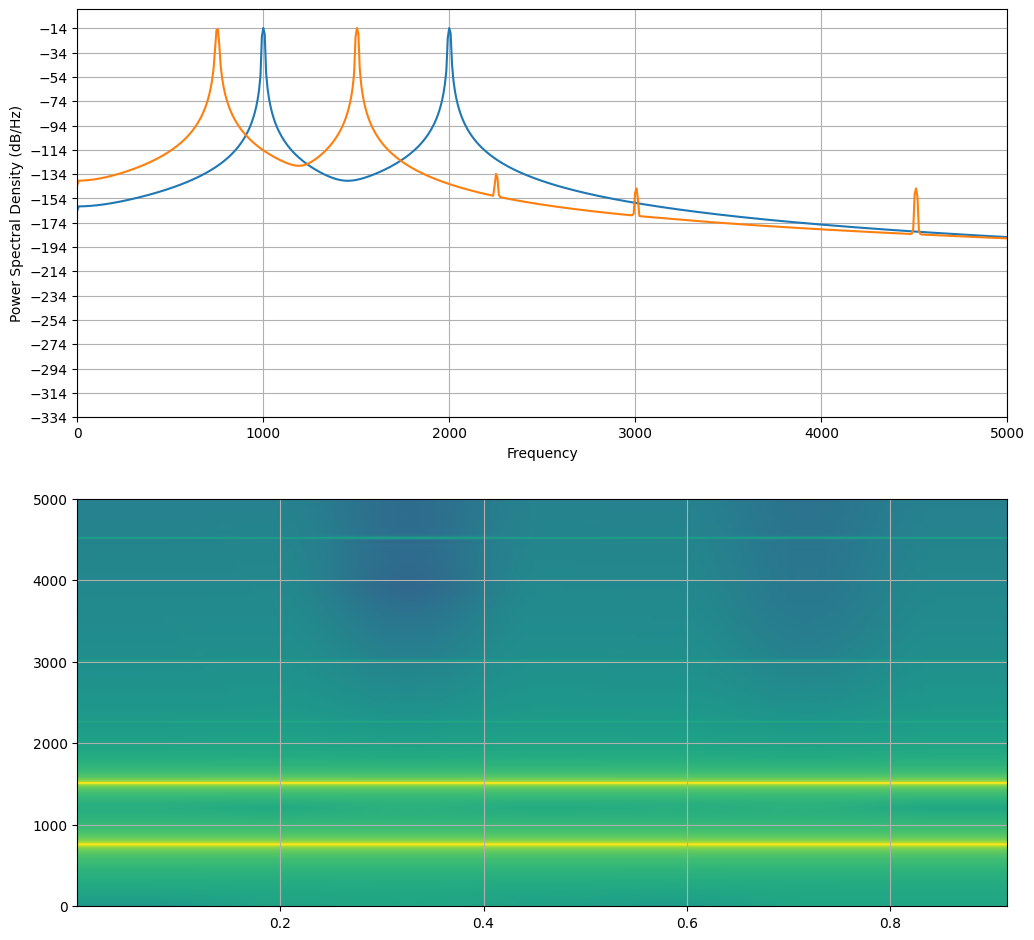

In [104]:
sample_rate = 500_000
#samples = 50_000_000
duration = 1.0
samples = int(duration * sample_rate)
t = np.arange(samples) / sample_rate

#frequency = 1300000000
frequencyA = 1_000
frequencyB = 2_000

# See https://en.wikipedia.org/wiki/Analytic_signal
y = np.exp(1j * 2 * np.pi * frequencyA * t)      # Analytic signal -- no negative frequencies!
y += np.exp(1j * 2 * np.pi * frequencyB * t)      # Analytic signal -- no negative frequencies!
#y = np.sin(2 * np.pi * frequency * t)      # Note: initial specgram only shows positive frequency?, but when shifted by Method 1, we get both positive and negative frequencies
#y = np.sin(t * frequency * 2 * np.pi) * 1j # Note: shows positive and negative frequencies throughout

# # Method 1: Frequency shifting by multiplying with complex exponential: output frequency = input frequency + shift
# # NOTE: This shifts *all* frequencies by the constant 'shift'
# shift = 500  # Constant f shift up
# #shift = 2_000 * t  # Linear f shift up
# #shift = -3_000 * t  # Linear f shift down
# #shift = 1_000 * t + 1000 * t**2 / 2  # Quadratic shift up
# y_shifted = y * np.exp(1j * 2 * np.pi * shift * t).T

# Method 2: Time scale shifting
# NOTE: This shifts frequencies *proportionately*, eg by 20%. Higher noise floor than Method 3, due to sampling effects?
#adjusted_t = np.linspace(0, duration * 0.8, samples)
adjusted_t = np.linspace(0, duration * 1.33, samples)
#f2 = scipy.interpolate.interp1d(adjusted_t, y, kind='previous', fill_value=0.0, bounds_error=False)
f2 = scipy.interpolate.interp1d(adjusted_t, y, kind='linear', fill_value=0.0, bounds_error=False)
#f2 = scipy.interpolate.interp1d(adjusted_t, y, kind='cubic', fill_value=0.0, bounds_error=False)
y_shifted = f2(t)

# # Method 3: Analytically regenerate the shifted signal!
# # NOTE: This shifts frequencies *proportionately*, eg by 25%
# d = 1.25
# t2 = np.linspace(0, duration * d, samples)
# y_shifted = np.exp(1j * 2 * np.pi * frequencyA * t2)
# y_shifted += np.exp(1j * 2 * np.pi * frequencyB * t2)

pl.figure(figsize=(12, 18))
#pl.subplot(3, 1, 1)
#Sxx_tx, f_tx, t_tx, image_tx = pl.specgram(y, Fs=sample_rate, NFFT=2**16)
#pl.gca().set_ylim(0, 5_000)
#pl.grid()
pl.subplot(3, 1, 2)
Pxx, freqs = pl.psd(np.real(y), Fs=sample_rate, NFFT=2**16)
Pxx, freqs = pl.psd(np.real(y_shifted), Fs=sample_rate, NFFT=2**16)
#Pxx, freqs = pl.psd(np.real(y_shifted2), Fs=sample_rate, NFFT=2**16)
pl.gca().set_xlim(0, 5_000)
pl.subplot(3, 1, 3)
Sxx_tx, f_tx, t_tx, image_tx = pl.specgram(np.real(y_shifted), Fs=sample_rate, NFFT=2**16)
pl.gca().set_ylim(0, 5_000)
pl.grid()